In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ---- CELLULE 1 : Installation ----
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 138.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.0 MB/s eta 0:00:00


In [3]:
# ---- CELLULE 2 : Import du dataset depuis Roboflow ----
from roboflow import Roboflow

rf = Roboflow(api_key="MGyf2MlIeUCGXuVuj0Gj")
project = rf.workspace("airborne-object-detection").project("airborne-object-detection-4-aod4")
version = project.version(4)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Airborne-Object-Detection-4-AOD4-4 in yolov8:: 100%|██████████| 42690/42690 [00:05<00:00, 7142.01it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# ---- CELLULE 3 : Vérification du dataset ----
import os
print("Dataset path:", dataset.location)
print("Contenu:", os.listdir(dataset.location))

# Vérifier le fichier data.yaml
yaml_path = os.path.join(dataset.location, "data.yaml")
with open(yaml_path, "r") as f:
    print("\ndata.yaml:")
    print(f.read())

Dataset path: /content/Airborne-Object-Detection-4-AOD4-4
Contenu: ['train', 'README.dataset.txt', 'valid', 'test', 'README.roboflow.txt', 'data.yaml']

data.yaml:
names:
- airplane
- bird
- drone
- helicopter
nc: 4
roboflow:
  license: CC BY 4.0
  project: air-borne-objects
  url: https://universe.roboflow.com/scaai-research-internship/air-borne-objects/dataset/4
  version: 4
  workspace: scaai-research-internship
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
# ---- CELLULE 4 : Fine-tuning YOLOv8n ----
from ultralytics import YOLO

# Charger le modèle YOLOv8n pré-entraîné
model = YOLO("yolov8n.pt")

# Lancer le fine-tuning
results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16,
    name="aod4_yolov8n",
    project="/content/drive/MyDrive/AOD4",
    patience=10,
    save=True,
    device=0  # GPU
)

Ultralytics 8.4.100 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Airborne-Object-Detection-4-AOD4-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=aod4_yolov8n, nbs=64, nms=False, opset=None, optimize=False

In [ ]:
# ---- CELLULE 5 : Évaluation sur le set de validation ----
from ultralytics import YOLO

# Charger le meilleur modèle
best_model = YOLO("/content/drive/MyDrive/AOD4/aod4_yolov8n/weights/best.pt")

# Évaluation
metrics = best_model.val(data=yaml_path)

print("\n=== RÉSULTATS ===")
print(f"mAP50   : {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall  : {metrics.box.mr:.3f}")

Ultralytics 8.4.100 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 739.5±405.4 MB/s, size: 15.2 KB)
val: Scanning /content/Airborne-Object-Detection-4-AOD4-4/valid/labels.cache... 4276 images, 111 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4276/4276 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 268/268 6.5it/s 41.1s
                   all       4276       6059      0.945      0.929      0.962       0.64
              airplane       1023       1529       0.95      0.919      0.958      0.673
                  bird        625       1487      0.936      0.947       0.97      0.682
                 drone       1427       1536      0.947      0.913      0.955      0.603
            helicopter       1099       1507      0.945      0.938      0.965      0.604
Speed: 1.2ms pr

Image testée: /content/Airborne-Object-Detection-4-AOD4-4/valid/images/V_DRONE_092202_195_png_jpg.rf.3f2b32d007de3f4b30ccf9fe2cd83184.jpg

image 1/1 /content/Airborne-Object-Detection-4-AOD4-4/valid/images/V_DRONE_092202_195_png_jpg.rf.3f2b32d007de3f4b30ccf9fe2cd83184.jpg: 640x640 1 drone, 12.0ms
Speed: 3.9ms preprocess, 12.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


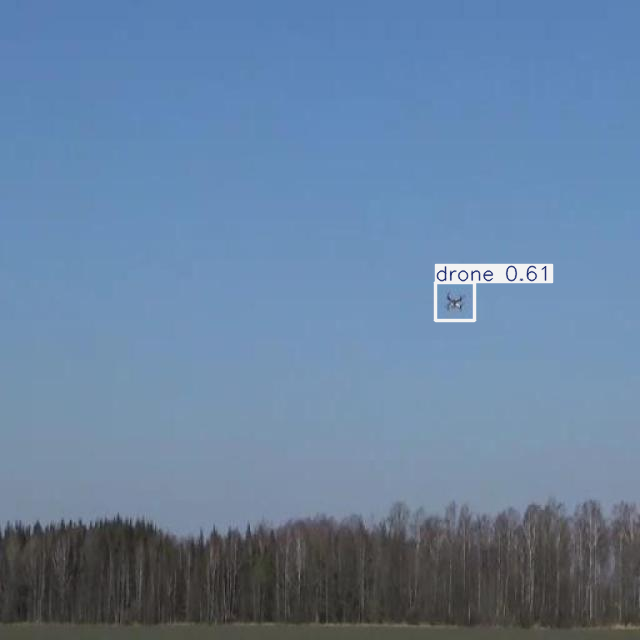

In [ ]:
# ---- CELLULE 6 : Test sur une image ----
import glob
import random

# Prendre une image aléatoire du set de validation
val_images = glob.glob(os.path.join(dataset.location, "valid/images/*.jpg"))
test_img = random.choice(val_images)
print("Image testée:", test_img)

# Prédiction
results = best_model.predict(test_img, conf=0.25, save=True)
results[0].show()

In [5]:
import os
print(os.path.exists("/content/Airborne-Object-Detection-4-AOD4-4"))

True


In [6]:
from ultralytics import YOLO
best_model = YOLO("/content/drive/MyDrive/AOD4/aod4_yolov8n/weights/best.pt")
print("Modèle chargé ✅")

Modèle chargé ✅


In [7]:
!pip install albumentations -q
import cv2
import numpy as np
import albumentations as A
print("Librairies OK ✅")

Librairies OK ✅


In [10]:
def apply_haze(image, t):
    """Haze: I_haze = I * t + 255 * (1 - t)"""
    image = image.astype(np.float32)
    hazy = image * t + 255 * (1 - t)
    return np.clip(hazy, 0, 255).astype(np.uint8)

def apply_blur(image, sigma):
    """Gaussian Blur"""
    kernel_size = int(6 * sigma + 1)
    if kernel_size % 2 == 0:
        kernel_size += 1
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

def apply_noise(image, sigma):
    """Gaussian Noise: I + N(0, sigma²)"""
    noise = np.random.normal(0, sigma, image.shape)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def apply_rain(image, drop_length, num_drops):
    """Rain streaks using albumentations"""
    transform = A.RandomRain(
        slant_lower=-10, slant_upper=10,
        drop_length=drop_length,
        drop_width=1,
        drop_color=(200, 200, 200),
        blur_value=1,
        brightness_coefficient=0.9,
        rain_type='default',
        p=1.0
    )
    return transform(image=image)['image']

def apply_lowlight(image, gamma):
    """Low-light: I_dark = (I/255)^gamma * 255"""
    image = image.astype(np.float32) / 255.0
    dark = np.power(image, gamma) * 255.0
    return np.clip(dark, 0, 255).astype(np.uint8)

def apply_jpeg(image, quality):
    """JPEG compression"""
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encoded = cv2.imencode('.jpg', image, encode_param)
    return cv2.imdecode(encoded, cv2.IMREAD_COLOR)

# Dictionnaire de toutes les corruptions et leurs paramètres
CORRUPTIONS = {
    "haze":     {"func": apply_haze,     "params": [("mild", 0.7), ("moderate", 0.5), ("severe", 0.3)]},
    "blur":     {"func": apply_blur,     "params": [("mild", 1.0), ("moderate", 2.0), ("severe", 3.0)]},
    "noise":    {"func": apply_noise,    "params": [("mild", 10),  ("moderate", 25),  ("severe", 50)]},
    "rain":     {"func": apply_rain,     "params": [("mild", (10, 50)), ("moderate", (20, 100)), ("severe", (30, 200))]},
    "lowlight": {"func": apply_lowlight, "params": [("mild", 1.5), ("moderate", 2.5), ("severe", 4.0)]},
    "jpeg":     {"func": apply_jpeg,     "params": [("mild", 60),  ("moderate", 30),  ("severe", 10)]},
}

print("Fonctions de corruption définies ✅")

Fonctions de corruption définies ✅


In [ ]:
import shutil
from pathlib import Path

val_img_dir = Path(dataset.location) / "valid" / "images"
val_lbl_dir = Path(dataset.location) / "valid" / "labels"
output_base = Path("/content/drive/MyDrive/AOD4/corrupted")

print(f"Images de validation : {len(list(val_img_dir.glob('*.jpg')))}")

for corruption_name, corruption_info in CORRUPTIONS.items():
    func = corruption_info["func"]
    for severity_name, param in corruption_info["params"]:
        # Créer le dossier de sortie
        out_img_dir = output_base / f"{corruption_name}_{severity_name}" / "images"
        out_lbl_dir = output_base / f"{corruption_name}_{severity_name}" / "labels"
        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)

        print(f"Génération : {corruption_name}_{severity_name}...", end=" ")

        for img_path in val_img_dir.glob("*.jpg"):
            # Lire l'image
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Appliquer la corruption
            if corruption_name == "rain":
                drop_length, num_drops = param
                corrupted = func(img, drop_length, num_drops)
            else:
                corrupted = func(img, param)

            # Sauvegarder l'image corrompue
            corrupted_bgr = cv2.cvtColor(corrupted, cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(out_img_dir / img_path.name), corrupted_bgr)

            # Copier le fichier label (annotations inchangées)
            lbl_path = val_lbl_dir / (img_path.stem + ".txt")
            if lbl_path.exists():
                shutil.copy(str(lbl_path), str(out_lbl_dir / lbl_path.name))

        print("✅")

print("\nToutes les corruptions générées ✅")

Images de validation : 4276
Génération : haze_mild... ✅
Génération : haze_moderate... ✅
Génération : haze_severe... ✅
Génération : blur_mild... ✅
Génération : blur_moderate... ✅
Génération : blur_severe... ✅
Génération : noise_mild... ✅
Génération : noise_moderate... ✅
Génération : noise_severe... ✅
Génération : rain_mild... 

Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain


✅
Génération : rain_moderate... ✅
Génération : rain_severe... ✅
Génération : lowlight_mild... ✅
Génération : lowlight_moderate... ✅
Génération : lowlight_severe... ✅
Génération : jpeg_mild... ✅
Génération : jpeg_moderate... ✅
Génération : jpeg_severe... ✅

Toutes les corruptions générées ✅


In [18]:
from pathlib import Path

output_base = Path("/content/drive/MyDrive/AOD4/corrupted")

print("Dossier :", output_base)
print("Existe :", output_base.exists())

Dossier : /content/drive/MyDrive/AOD4/corrupted
Existe : True


In [19]:
print(list(output_base.iterdir()))

[PosixPath('/content/drive/MyDrive/AOD4/corrupted/haze_mild'), PosixPath('/content/drive/MyDrive/AOD4/corrupted/haze_moderate'), PosixPath('/content/drive/MyDrive/AOD4/corrupted/haze_severe'), PosixPath('/content/drive/MyDrive/AOD4/corrupted/blur_mild'), PosixPath('/content/drive/MyDrive/AOD4/corrupted/blur_moderate'), PosixPath('/content/drive/MyDrive/AOD4/corrupted/blur_severe'), PosixPath('/content/drive/MyDrive/AOD4/corrupted/noise_mild'), PosixPath('/content/drive/MyDrive/AOD4/corrupted/noise_moderate'), PosixPath('/content/drive/MyDrive/AOD4/corrupted/noise_severe'), PosixPath('/content/drive/MyDrive/AOD4/corrupted/rain_mild')]


In [21]:
from ultralytics import YOLO

# Charger le meilleur modèle
best_model = YOLO("/content/drive/MyDrive/AOD4/aod4_yolov8n/weights/best.pt")

In [16]:
import pandas as pd
import shutil
import random
from pathlib import Path

# Classes AOD-4
CLASSES = ["airplane", "bird", "drone", "helicopter"]
baseline_map50 = 0.962

# ── Créer un sous-ensemble de 500 images ──
val_img_dir = Path(dataset.location) / "valid" / "images"
val_lbl_dir = Path(dataset.location) / "valid" / "labels"

subset_dir = Path("/content/subset_val")
subset_img = subset_dir / "images"
subset_lbl = subset_dir / "labels"
subset_img.mkdir(parents=True, exist_ok=True)
subset_lbl.mkdir(parents=True, exist_ok=True)

all_imgs = list(val_img_dir.glob("*.jpg"))
subset_imgs = random.sample(all_imgs, min(500, len(all_imgs)))

for img_path in subset_imgs:
    shutil.copy(str(img_path), str(subset_img / img_path.name))
    lbl_path = val_lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        shutil.copy(str(lbl_path), str(subset_lbl / lbl_path.name))

print(f"Subset créé : {len(subset_imgs)} images ✅")

# ── Évaluation ──
results = []

for corruption_name, corruption_info in CORRUPTIONS.items():
    func = corruption_info["func"]
    for severity_name, param in corruption_info["params"]:

        # Générer les images corrompues du subset
        corrupt_dir = Path(f"/content/subset_{corruption_name}_{severity_name}")
        corrupt_img = corrupt_dir / "images"
        corrupt_lbl = corrupt_dir / "labels"
        corrupt_img.mkdir(parents=True, exist_ok=True)
        corrupt_lbl.mkdir(parents=True, exist_ok=True)

        for img_path in subset_img.glob("*.jpg"):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if corruption_name == "rain":
                drop_length, num_drops = param
                corrupted = func(img, drop_length, num_drops)
            else:
                corrupted = func(img, param)

            corrupted_bgr = cv2.cvtColor(corrupted, cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(corrupt_img / img_path.name), corrupted_bgr)

            lbl_path = subset_lbl / (img_path.stem + ".txt")
            if lbl_path.exists():
                shutil.copy(str(lbl_path), str(corrupt_lbl / lbl_path.name))

        # data.yaml temporaire
        yaml_content = f"""path: {corrupt_dir}
train: images
val: images
nc: 4
names: ['airplane', 'bird', 'drone', 'helicopter']
"""
        yaml_tmp = corrupt_dir / "data.yaml"
        with open(str(yaml_tmp), "w") as f:
            f.write(yaml_content)

        # Évaluation
        metrics = best_model.val(
            data=str(yaml_tmp),
            verbose=False,
            plots=False,
            workers=0
        )

        map50 = metrics.box.map50
        map50_95 = metrics.box.map
        drop = (baseline_map50 - map50) / baseline_map50 * 100

        results.append({
            "corruption": corruption_name,
            "severity": severity_name,
            "mAP50": round(map50, 3),
            "mAP50-95": round(map50_95, 3),
            "drop_%": round(drop, 1),
        })

        print(f"{corruption_name}_{severity_name}: mAP50={map50:.3f} (chute: {drop:.1f}%)")

# Tableau final
df = pd.DataFrame(results)
print("\n=== TABLEAU DE ROBUSTESSE ===")
print(df.to_string(index=False))
df.to_csv("/content/drive/MyDrive/AOD4/robustness_results.csv", index=False)
print("\nRésultats sauvegardés ✅")

Subset créé : 500 images ✅
Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1083.0±547.6 MB/s, size: 40.8 KB)
val: Scanning /content/subset_haze_mild/labels... 500 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 1.6Kit/s 0.3s
val: New cache created: /content/subset_haze_mild/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 6.0it/s 5.4s
                   all        500        745      0.937      0.894      0.956       0.62
Speed: 0.4ms preprocess, 4.0ms inference, 0.0ms loss, 0.8ms postprocess per image
haze_mild: mAP50=0.956 (chute: 0.6%)
Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1385.5±614.8 MB/s, size: 37.6 KB)
val: Scanning /content/subset_haze_moderate/labels... 500 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━

Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain


Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1754.0±412.8 MB/s, size: 64.4 KB)
val: Scanning /content/subset_rain_mild/labels... 500 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 2.2Kit/s 0.2s
val: New cache created: /content/subset_rain_mild/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 6.4it/s 5.0s
                   all        500        745      0.736       0.39       0.51      0.311
Speed: 0.4ms preprocess, 3.6ms inference, 0.0ms loss, 1.1ms postprocess per image
rain_mild: mAP50=0.510 (chute: 46.9%)
Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2130.2±565.4 MB/s, size: 76.1 KB)
val: Scanning /content/subset_rain_moderate/labels... 500 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 2.0Kit/s 0.2s
val

In [12]:
from pathlib import Path

folder = Path("/content/subset_haze_mild/images")

print("Nombre total de fichiers :", len(list(folder.iterdir())))
print("JPG :", len(list(folder.glob("*.jpg"))))
print("JPEG :", len(list(folder.glob("*.jpeg"))))
print("PNG :", len(list(folder.glob("*.png"))))

Nombre total de fichiers : 940
JPG : 940
JPEG : 0
PNG : 0


In [13]:
print(list(folder.iterdir())[:20])

[PosixPath('/content/subset_haze_mild/images/V_DRONE_087197_236_png_jpg.rf.4f655c6ef2158cabbc2c51f5159fb8d1.jpg'), PosixPath('/content/subset_haze_mild/images/20190926_183941_1_1_779_jpg.rf.fd04680287dbdd174c9bcf7b906d6800.jpg'), PosixPath('/content/subset_haze_mild/images/V_AIRPLANE_04343_216_png_jpg.rf.f018608d391a184790923e989c5a70c7.jpg'), PosixPath('/content/subset_haze_mild/images/20190925_194211_1_8_127_jpg.rf.a7ef0509f112e4d0630eb192e8f9c77e.jpg'), PosixPath('/content/subset_haze_mild/images/yt-0BFf4YWpzHM-0162_jpg.rf.cef22b8bc3d3f7151a030f43f5064510.jpg'), PosixPath('/content/subset_haze_mild/images/V_DRONE_036146_210_png_jpg.rf.ae7637e920058146b1ab2905afd233b9.jpg'), PosixPath('/content/subset_haze_mild/images/lenstravelier-vVRVt2e1gS4-unsplash_jpg.rf.f4cc30ee7ae0387c31d9c1eb04f1247a.jpg'), PosixPath('/content/subset_haze_mild/images/V_HELICOPTER_010234_257_png_jpg.rf.4e580d6b89f31d48f5800be473871523.jpg'), PosixPath('/content/subset_haze_mild/images/20190925_140917_1_4_850_j

In [14]:
import shutil
from pathlib import Path

# Supprimer l'ancien sous-ensemble
subset_val = Path("/content/subset_val")

if subset_val.exists():
    shutil.rmtree(subset_val)

# Supprimer les anciennes corruptions du sous-ensemble
for corruption_name, corruption_info in CORRUPTIONS.items():
    for severity_name, param in corruption_info["params"]:
        corrupt_dir = Path(
            f"/content/subset_{corruption_name}_{severity_name}"
        )

        if corrupt_dir.exists():
            shutil.rmtree(corrupt_dir)

print("✅ Anciens sous-ensembles supprimés")

✅ Anciens sous-ensembles supprimés
